# ICG for the 300x300 system

In this notebook, we implement the ICG to apply it on the 300x300 system, using the SciPy implementation of the regular CG. 

In [2]:
from pathlib import Path
import numpy as np

base_dir = Path("system_303")

A = np.genfromtxt(base_dir / "stiffness_beam_A.dat", delimiter=",")[3:, 3:]
b = np.genfromtxt(base_dir / "forcing_b.dat")[3:]
box = np.genfromtxt(base_dir / "B0_wide_bc.dat", delimiter=",")
x_star = np.genfromtxt(base_dir / "soln_x.dat")[3:]

ell0 = box[3:, 0]
u0 = box[3:, 1]


In [3]:
# add here the smallest and biggest eigenvals and conditioning number of A, and then of A_hat
diag_A = np.diag(A)
if np.any(diag_A <= 0):
    raise ValueError("Jacobi scaling requires a positive diagonal.")

scale = np.sqrt(diag_A)
A_hat = A / scale[:, None] / scale[None, :]

eigvals_A = np.linalg.eigvalsh(A)
eigvals_A_hat = np.linalg.eigvalsh(A_hat)

condition_A = eigvals_A[-1] / eigvals_A[0]
condition_A_hat = eigvals_A_hat[-1] / eigvals_A_hat[0]

print("A:")
print(f"  smallest eigenvalue: {eigvals_A[0]:.16e}")
print(f"  biggest eigenvalue:  {eigvals_A[-1]:.16e}")
print(f"  condition number:    {condition_A:.16e}")

print("\nA_hat:")
print(f"  smallest eigenvalue: {eigvals_A_hat[0]:.16e}")
print(f"  biggest eigenvalue:  {eigvals_A_hat[-1]:.16e}")
print(f"  condition number:    {condition_A_hat:.16e}")


A:
  smallest eigenvalue: 7.0008220394031389e+02
  biggest eigenvalue:  3.2879900893790034e+12
  condition number:    4.6965771603291941e+09

A_hat:
  smallest eigenvalue: 2.9392884118717852e-08
  biggest eigenvalue:  2.6861406616345080e+00
  condition number:    9.1387447750455067e+07


SciPy CG info: 0 (0 means converged)
SciPy CG iterations recorded: 1045
SciPy CG final residual norm: 2.689679668114071e-09


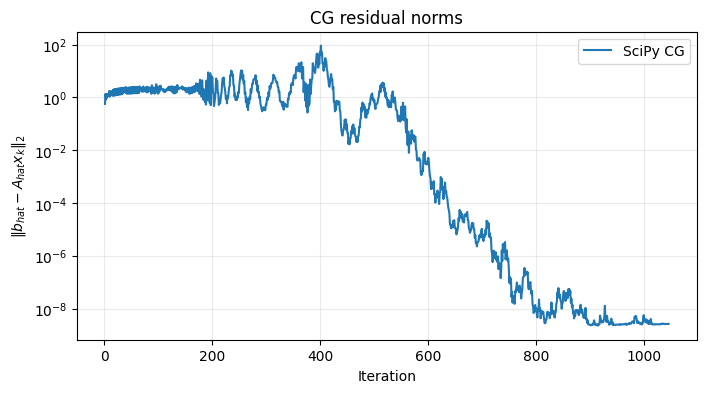

In [4]:
from scipy.sparse.linalg import cg
import matplotlib.pyplot as plt

if "b_hat" not in globals():
    b_hat = b / scale

_cg_A = A_hat
_cg_b = b_hat
_cg_rtol = 1e-10
_cg_atol = 0.0
_cg_maxiter = 10_000

scipy_residual_norms = []


def record_scipy_residual(xk):
    scipy_residual_norms.append(np.linalg.norm(_cg_b - _cg_A @ xk))


x_scipy_cg, scipy_cg_info = cg(
    _cg_A,
    _cg_b,
    rtol=_cg_rtol,
    atol=_cg_atol,
    maxiter=_cg_maxiter,
    callback=record_scipy_residual,
)

print("SciPy CG info:", scipy_cg_info, "(0 means converged)")
print("SciPy CG iterations recorded:", len(scipy_residual_norms))
print("SciPy CG final residual norm:", scipy_residual_norms[-1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(range(1, len(scipy_residual_norms) + 1), scipy_residual_norms, label="SciPy CG")
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$\|b_{hat} - A_{hat} x_k\|_2$")
ax.set_title("CG residual norms")
ax.grid(alpha=0.25, which="both")
ax.legend()
plt.show()


In [5]:
def cg_with_direction_callback(
    A,
    b,
    x0=None,
    rtol=1e-8,
    atol=0.0,
    maxiter=None,
    M=None,
    callback=None,
    direction_callback=None,
):
    b = np.asarray(b)
    n = b.shape[0]
    x = np.zeros_like(b) if x0 is None else np.array(x0, dtype=b.dtype, copy=True)

    def matvec(v):
        if callable(A):
            return np.asarray(A(v))
        if hasattr(A, "matvec"):
            return np.asarray(A.matvec(v))
        return np.asarray(A @ v)

    def psolve(v):
        if M is None:
            return v.copy()
        if callable(M):
            return np.asarray(M(v))
        if hasattr(M, "matvec"):
            return np.asarray(M.matvec(v))
        return np.asarray(M @ v)

    if maxiter is None:
        maxiter = n * 10

    bnrm2 = np.linalg.norm(b)
    atol_threshold = max(float(atol), float(rtol) * bnrm2)

    r = b - matvec(x) if x0 is not None else b.copy()
    if np.linalg.norm(r) < atol_threshold:
        return x, 0

    rho_prev = None
    p = None

    for k in range(maxiter):
        z = psolve(r)
        rho_cur = np.dot(r, z)

        if k > 0:
            beta = rho_cur / rho_prev
            p = z + beta * p
        else:
            p = z.copy()

        q = matvec(p)
        if direction_callback is not None:
            direction_callback(k, x.copy(), r.copy(), p.copy(), q.copy())

        alpha = rho_cur / np.dot(p, q)
        x += alpha * p
        r -= alpha * q

        if callback is not None:
            callback(x.copy())

        if np.linalg.norm(r) < atol_threshold:
            return x, 0

        rho_prev = rho_cur

    return x, maxiter


Custom CG info: 0 (0 means converged)
Custom CG iterations recorded: 1045
Custom CG final residual norm: 2.689679668114071e-09
P_cg shape: (1045, 300)
Q_cg shape: (1045, 300)
c_cg shape: (1045,)


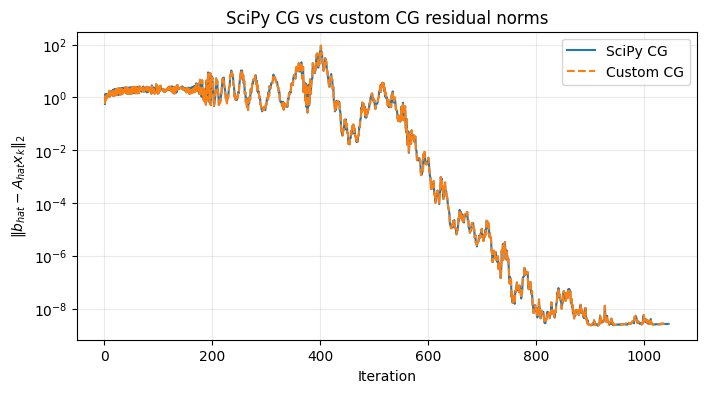

In [6]:
custom_residual_norms = []
p_list = []
q_list = []
c_list = []


def record_custom_residual(xk):
    custom_residual_norms.append(np.linalg.norm(_cg_b - _cg_A @ xk))


def record_direction(k, x, r, p, q):
    p_list.append(p)
    q_list.append(q)
    c_list.append(np.dot(p, _cg_b))


x_custom_cg, custom_cg_info = cg_with_direction_callback(
    _cg_A,
    _cg_b,
    rtol=_cg_rtol,
    atol=_cg_atol,
    maxiter=_cg_maxiter,
    callback=record_custom_residual,
    direction_callback=record_direction,
)

P_cg = np.vstack(p_list)
Q_cg = np.vstack(q_list)
c_cg = np.array(c_list)

print("Custom CG info:", custom_cg_info, "(0 means converged)")
print("Custom CG iterations recorded:", len(custom_residual_norms))
print("Custom CG final residual norm:", custom_residual_norms[-1])
print("P_cg shape:", P_cg.shape)
print("Q_cg shape:", Q_cg.shape)
print("c_cg shape:", c_cg.shape)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(range(1, len(scipy_residual_norms) + 1), scipy_residual_norms, label="SciPy CG")
ax.semilogy(
    range(1, len(custom_residual_norms) + 1),
    custom_residual_norms,
    "--",
    label="Custom CG",
)
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$\|b_{hat} - A_{hat} x_k\|_2$")
ax.set_title("SciPy CG vs custom CG residual norms")
ax.grid(alpha=0.25, which="both")
ax.legend()
plt.show()


In [7]:
import numpy as np

# Q_cg has shape (1045, 300)
s = np.linalg.svd(Q_cg, compute_uv=False)

print("Q_cg shape:", Q_cg.shape)
print("Largest singular value:", s[0])
print("Smallest singular value:", s[-1])

for tol in [1e-8, 1e-10, 1e-12, 1e-14]:
    rank = np.sum(s > tol * s[0])
    print(f"relative tol {tol:g}: numerical rank = {rank}")

Q_cg shape: (1045, 300)
Largest singular value: 56.985646450405916
Smallest singular value: 0.0
relative tol 1e-08: numerical rank = 200
relative tol 1e-10: numerical rank = 200
relative tol 1e-12: numerical rank = 200
relative tol 1e-14: numerical rank = 200


In [9]:
constraint_residual = Q_cg @ x_custom_cg - c_cg

print("max constraint residual:", np.max(np.abs(constraint_residual)))
print("norm constraint residual:", np.linalg.norm(constraint_residual))
print("relative constraint residual:",
      np.linalg.norm(constraint_residual) / np.linalg.norm(c_cg))

max constraint residual: 1.4768506844120566e-06
norm constraint residual: 3.035702805913046e-06
relative constraint residual: 3.021645920418708e-10


## Box Minimization

In [11]:
import numpy as np
from scipy.linalg import qr
from scipy.optimize import linprog

row_norms = np.linalg.norm(Q_cg, axis=1)
nonzero = row_norms > 0

Qn_all = Q_cg[nonzero] / row_norms[nonzero, None]
cn_all = c_cg[nonzero] / row_norms[nonzero]

QT = Qn_all.T

_, R, piv = qr(QT, pivoting=True, mode="economic")

diag_R = np.abs(np.diag(R))
tol = 1e-10 * diag_R[0]

rank = int(np.sum(diag_R > tol))
selected = piv[:rank]

Q_ind = Qn_all[selected]
c_ind = cn_all[selected]

print("Selected rank:", rank)
print("Q_ind shape:", Q_ind.shape)

Selected rank: 200
Q_ind shape: (200, 300)


In [12]:
constraint_residual_ind = Q_ind @ x_custom_cg - c_ind

print("max selected normalized residual:",
      np.max(np.abs(constraint_residual_ind)))

print("norm selected normalized residual:",
      np.linalg.norm(constraint_residual_ind))

max selected normalized residual: 1.4521958746627206e-08
norm selected normalized residual: 3.165886658241505e-08


In [13]:
observed_tau = np.max(np.abs(constraint_residual_ind))

tau = max(10.0 * observed_tau, 1e-10)

print("Using tau:", tau)

Using tau: 1.4521958746627206e-07


In [14]:
# If scale = sqrt(diag(A_original))
ell_hat = scale * ell0
u_hat = scale * u0

In [15]:
def coordinate_bounds_from_relaxed_constraints(Q, c, ell, u, tau, highs_method="highs"):
    n = len(ell)

    A_ub = np.vstack([Q, -Q])
    b_ub = np.concatenate([c + tau, -c + tau])

    bounds = list(zip(ell, u))

    ell_new = np.empty(n)
    u_new = np.empty(n)

    for i in range(n):
        obj = np.zeros(n)
        obj[i] = 1.0

        res_min = linprog(
            obj,
            A_ub=A_ub,
            b_ub=b_ub,
            bounds=bounds,
            method=highs_method,
        )

        if not res_min.success:
            raise RuntimeError(f"Min LP failed at coordinate {i}: {res_min.message}")

        ell_new[i] = res_min.fun

        res_max = linprog(
            -obj,
            A_ub=A_ub,
            b_ub=b_ub,
            bounds=bounds,
            method=highs_method,
        )

        if not res_max.success:
            raise RuntimeError(f"Max LP failed at coordinate {i}: {res_max.message}")

        u_new[i] = -res_max.fun

    return ell_new, u_new

ell_y, u_y = coordinate_bounds_from_relaxed_constraints(
    Q=Q_ind,
    c=c_ind,
    ell=ell_hat,
    u=u_hat,
    tau=tau,
)

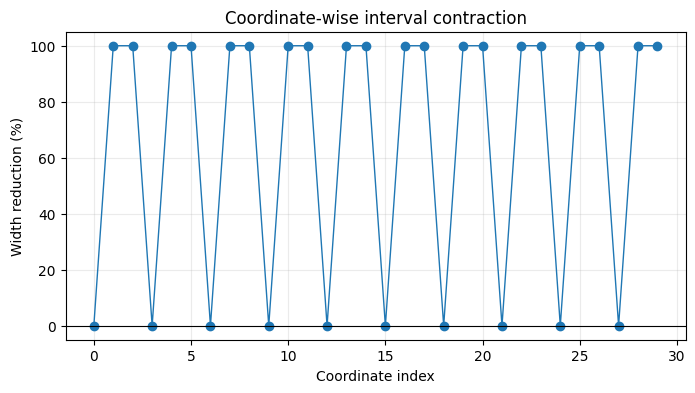

mean contraction %: 66.66666595567663
median contraction %: 99.99999810982521
min contraction %: 0.0
max contraction %: 99.99999999957556


In [ ]:
ell_x = ell_y / scale
u_x = u_y / scale

final_width = u_y - ell_y
initial_width = u_hat - ell_hat

contraction_ratio = final_width / initial_width

initial_width = u_hat - ell_hat
final_width = u_y - ell_y

with np.errstate(divide="ignore", invalid="ignore"):
    contraction_pct = 100 * (1 - final_width / initial_width)

plt.figure(figsize=(8, 4))
plt.plot(contraction_pct, marker="o", linewidth=1)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Coordinate index")
plt.ylabel("Width reduction (%)")
plt.title("Coordinate-wise interval contraction")
plt.grid(alpha=0.25)
plt.show()

print("mean contraction %:", np.nanmean(contraction_pct))
print("median contraction %:", np.nanmedian(contraction_pct))
print("min contraction %:", np.nanmin(contraction_pct))
print("max contraction %:", np.nanmax(contraction_pct))